# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

Nesse projeto trabalharemos com a base de dados de produtos de um supermercado do Chile.
A ideia é que vocês apliquem os conceitos estatísticos vistos no último módulo, mais os conceitos de visualizações de dados através de gráficos e finalizem publicando no seu github!

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

Faça a leitura dos dados do arquivo CSV:


Altere o código abaixo de acordo com seu diretório.

In [ ]:
df = pd.read_csv("MODULO7_PROJETOFINAL_BASE_SUPERMERCADO.csv", delimiter=',')

df.head(10)

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
5,"Pack 12 un, Leche sin lactosa frutilla 1 L",Loncoleche,17988,0,0,0,lacteos
6,"Pack 12 un, Leche saborizada light chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
7,"Pack 12 un, Leche saborizada frutilla 1 L",Colun,17388,0,0,0,lacteos
8,"Pack 12 un, Leche saborizada vainilla 1 L",Colun,17388,0,0,0,lacteos
9,"Pack 12 un, Leche saborizada manjar 1 L",Colun,17388,0,0,0,lacteos


In [ ]:
df.tail(10)

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
1097,"Helado multipack Frugelé 18 un, 60 ml c/u",Bresler,0,4509,5499,990,congelados
1098,"Jabón barra original 3 un, de 90 g",Dove,0,2659,3659,1000,belleza-y-cuidado-personal
1099,Shampoo Fuerza Extrema 400 ml,Dove Men,0,2690,3699,1009,belleza-y-cuidado-personal
1100,Postre helado chocolate blanco frambuesa 900 ml,Magnum,0,4279,5349,1070,congelados
1101,Postre helado chocolate nuss 900 ml,Magnum,0,4279,5349,1070,congelados
1102,"Helado bresler pote cassata 2,4l",Bresler,0,4359,5449,1090,congelados
1103,"Helado Trisabor chocolate lúcuma y manjar 2,4 L",Bresler,0,4359,5449,1090,congelados
1104,Shampoo Reconstrucción Completa 400 ml,Dove,0,2690,3849,1159,belleza-y-cuidado-personal
1105,Acondicionador Hidratación Intensa 400 ml,Dove,0,2690,3849,1159,belleza-y-cuidado-personal
1106,Leche en Polvo Nido Forticrece Sin lactosa 1440g,Nido,0,14550,18899,4349,lacteos


Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1107 entries, 0 to 1106
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   title           1107 non-null   object
 1   Marca           1107 non-null   object
 2   Preco_Normal    1107 non-null   int64 
 3   Preco_Desconto  1107 non-null   int64 
 4   Preco_Anterior  1107 non-null   int64 
 5   Desconto        1107 non-null   int64 
 6   Categoria       1107 non-null   object
dtypes: int64(4), object(3)
memory usage: 60.7+ KB


# 1 - Traga a média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identifique as categorias que parecem ter um valor de média abaixo ou acima da mediana.

In [ ]:
#Seu código aqui para a média
df_media_categoria = df.groupby('Categoria')['Preco_Normal'].mean().reset_index().sort_values('Preco_Normal', ascending=False)
df_media_categoria

,Categoria,Preco_Normal
1,comidas-preparadas,3095.043478
5,lacteos,2385.219239
2,congelados,2108.042553
0,belleza-y-cuidado-personal,1783.556485
3,frutas,1724.473684
6,verduras,1343.296875
4,instantaneos-y-sopas,765.491228


In [ ]:
#Seu código aqui para a mediana
df_mediana_categoria = df.groupby('Categoria')['Preco_Normal'].median().reset_index().sort_values('Preco_Normal', ascending=False)
df_mediana_categoria

,Categoria,Preco_Normal
1,comidas-preparadas,3290.0
0,belleza-y-cuidado-personal,1569.0
2,congelados,1519.0
3,frutas,1195.0
6,verduras,1180.0
5,lacteos,989.0
4,instantaneos-y-sopas,439.0


### Digite aqui as categorias:

As Categorias que mais apresentaram diferença entre a Média e a Mediana foram: *lacteos; congelados; instantaneos-y-sopas*. Em que a categoria *lacteos* é a que mais apresenta discrepância entre todas as outras.

Categorias em que a Média foi **maior** que a Mediana:
*lacteos; congelados; belleza-y-cuidado-personal; frutas; verduras; instantaneos-y-sopas*.

Categoria em que a Média foi **menor** que a Mediana:
*comidas-preparadas*.

# 2 - Traga o desvio padrão por categoria de produto.
# Qual o comportamento da média e mediana nas categorias com maior desvio?

In [ ]:
#Seu código aqui
desvio_padrao_categoria = df.groupby('Categoria')['Preco_Normal'].std().reset_index()
desvio_padrao_categoria

,Categoria,Preco_Normal
0,belleza-y-cuidado-personal,2210.041719
1,comidas-preparadas,2019.911428
2,congelados,2111.539896
3,frutas,1639.151114
4,instantaneos-y-sopas,1170.232869
5,lacteos,3925.816164
6,verduras,1012.699625


### Digite nesse campo o comportamento que você identificou.

As categorias com o maior desvio padrão são:
*lacteos; belleza-y-cuidado-personal; congelados; e comidas-preparadas*

Quanto maior o desvio padrão, menos homogêneos serão os dados e valores estudados. Dessa forma, os valores da Média e Mediana tendem a se dissipar mais e serão mais discrepantes entre si conforme o aumento do Desvio Padrão.

# 3 - Plot um boxplot da distribuição do Preco_Normal para a categoria que você identificou que tem o maior desvio padrão. Como é a distribuição desses dados segundo o boxplot? Você identifica muitos outliers?

Dica: Para trazer apenas os dados da categoria que você deseja você pode usar o df.loc[df['Categoria'] == 'CATEGORIA ESCOLHIDA'

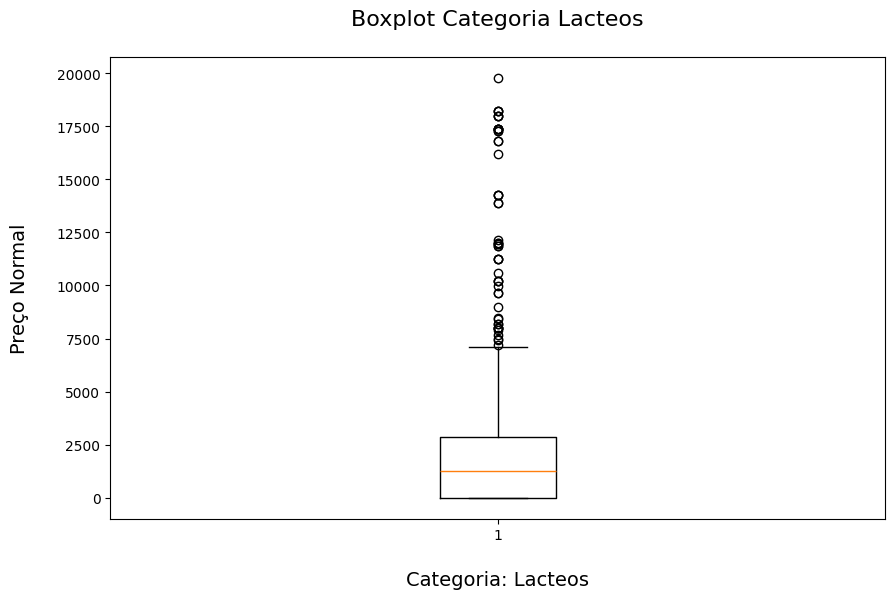

In [ ]:
#Seu código aqui

df.loc[df['Categoria'] == 'lacteos']

plt.figure(figsize=(10, 6))
plt.boxplot(df['Preco_Normal'])

plt.title('Boxplot Categoria Lacteos\n', fontsize = 16)
plt.xlabel('\nCategoria: Lacteos', fontsize = 14)
plt.ylabel('Preço Normal\n', fontsize = 14)

plt.show()

### 3) Há diversos outliers no "Preco_Normal" da categoria "lacteos". Segundo o boxplot, a distribuição está completamente irregular.

# 4 - Plote um gráfico de barras onde temos a média de descontos por categoria.

In [ ]:
df_media_desconto = df.groupby('Categoria')['Desconto'].mean().reset_index().sort_values('Desconto', ascending=False)

df_media_desconto

,Categoria,Desconto
2,congelados,154.029787
0,belleza-y-cuidado-personal,123.083682
1,comidas-preparadas,43.478261
5,lacteos,17.411633
3,frutas,0.000000
4,instantaneos-y-sopas,0.000000
6,verduras,0.000000


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'congelados'),
  Text(1, 0, 'belleza-y-cuidado-personal'),
  Text(2, 0, 'comidas-preparadas'),
  Text(3, 0, 'lacteos'),
  Text(4, 0, 'frutas'),
  Text(5, 0, 'instantaneos-y-sopas'),
  Text(6, 0, 'verduras')])

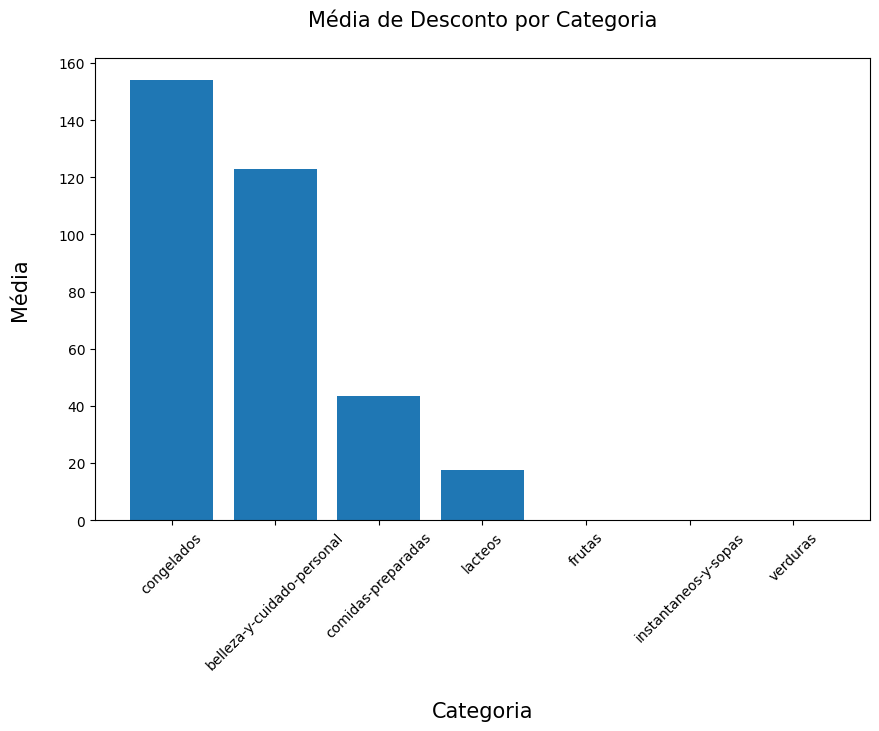

In [ ]:
# Seu código aqui

plt.figure(figsize = (10,6))
plt.bar(df_media_desconto['Categoria'], df_media_desconto['Desconto'])

plt.title('Média de Desconto por Categoria\n', fontsize = 15)
plt.xlabel('\nCategoria', fontsize = 15)
plt.ylabel('Média\n', fontsize = 15)

plt.xticks(rotation = 45)

# 5 - Plote um gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

In [ ]:
media_desconto_categ_marca =df.groupby(['Categoria', 'Marca'])['Desconto'].mean().reset_index()

media_desconto_categ_marca

,Categoria,Marca,Desconto
0,belleza-y-cuidado-personal,Always,123.750000
1,belleza-y-cuidado-personal,Aquafresh,444.666667
2,belleza-y-cuidado-personal,Axe,590.000000
3,belleza-y-cuidado-personal,Babyland,0.000000
4,belleza-y-cuidado-personal,Ballerina,34.083333
...,...,...,...
162,lacteos,Zerolacto,0.000000
163,verduras,Agrosano,0.000000
164,verduras,Dole,0.000000
165,verduras,Frutas Y Verduras Propias,0.000000


In [ ]:
# Seu código aqui

fig = px.treemap(media_desconto_categ_marca,
                 path=['Categoria', 'Marca'],
                 values='Desconto',
                 title = 'Desconto por Categoria e Marca',
                 color = 'Marca')

fig.show()